# CNN + BiLSTM — EMG2QWERTY Training Notebook

This notebook trains, validates, and tests the `CNNBiLSTMCTCModule` end-to-end.

**Pipeline:**
```
Raw EMG  →  LogSpectrogram  →  SpectrogramNorm
         →  MultiBandRotationInvariantMLP
         →  CNNBiLSTMEncoder  (Conv1d × 3 → BiLSTM)
         →  Linear  →  LogSoftmax  →  CTC Loss
```

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install pytorch_lightning
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 74.6 MB/s eta 0:00:00
     \ 553.6 kB 553.2 kB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want

In [1]:
cd /content/drive/MyDrive/winter_2026/ecec247a/final_project/emg2qwerty/

/content/drive/MyDrive/winter_2026/ecec247a/final_project/emg2qwerty


## 2. Training

In [2]:
!python -m emg2qwerty.train \
  model=cnn_bilstm_ctc \
  trainer.accelerator=gpu trainer.devices=1 \
  --multirun

[2026-03-13 05:55:08,725][HYDRA] Submitit 'local' sweep output dir : logs/2026-03-13/05-55-08
[2026-03-13 05:55:08,727][HYDRA] 	#0 : model=cnn_bilstm_ctc trainer.accelerator=gpu trainer.devices=1


## 3. Testing

In [5]:
!python -m emg2qwerty.train \
  model=cnn_bilstm_ctc \
  "checkpoint='logs/2026-03-13/05-55-08/job0_model=cnn_bilstm_ctc,trainer.devices=1/checkpoints/epoch=139-step=16800.ckpt'" \
  train=False \
  trainer.accelerator=gpu trainer.devices=1 \
  decoder=ctc_greedy

[2026-03-13 07:05:05,414][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

## 4. Loss & CER Curves

Available tags: ['hp_metric', 'lr-Adam', 'train/loss', 'epoch', 'val/loss', 'val/CER', 'val/IER', 'val/DER', 'val/SER', 'train/CER', 'train/IER', 'train/DER', 'train/SER', 'test/loss', 'test/CER', 'test/IER', 'test/DER', 'test/SER']


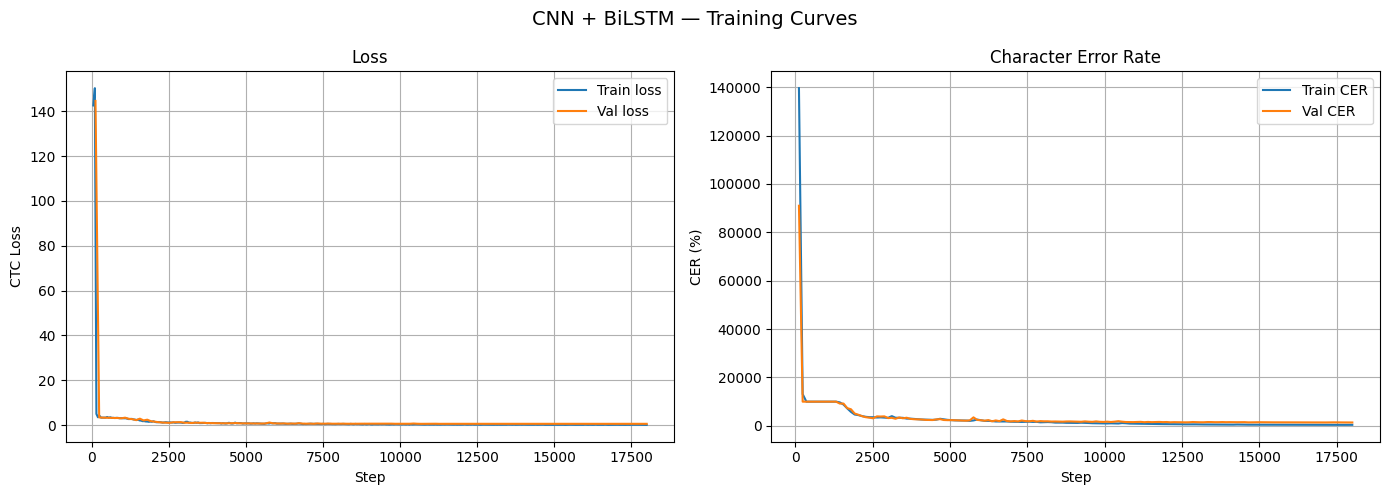

In [10]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

events_dir = "logs/2026-03-13/05-55-08/job0_model=cnn_bilstm_ctc,trainer.devices=1/lightning_logs/version_0"
ea = EventAccumulator(events_dir)
ea.Reload()

def to_df(tag):
    events = ea.Scalars(tag)
    return pd.DataFrame({"step": [e.step for e in events], "value": [e.value for e in events]})

print("Available tags:", ea.Tags()["scalars"])  # see what's logged

train_loss = to_df("train/loss")
val_loss   = to_df("val/loss")
train_cer  = to_df("train/CER")
val_cer    = to_df("val/CER")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss["step"], train_loss["value"], label="Train loss")
axes[0].plot(val_loss["step"],   val_loss["value"],   label="Val loss")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("CTC Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_cer["step"], train_cer["value"] * 100, label="Train CER")
axes[1].plot(val_cer["step"],   val_cer["value"] * 100,   label="Val CER")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("CER (%)")
axes[1].set_title("Character Error Rate"); axes[1].legend(); axes[1].grid(True)

plt.suptitle("CNN + BiLSTM — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Summary

In [22]:
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RUN_DIR = Path("logs/2026-03-13/05-55-08/job0_model=cnn_bilstm_ctc,trainer.devices=1")

events_dir = str(next(RUN_DIR.glob("lightning_logs/version_*/")))
ea = EventAccumulator(events_dir)
ea.Reload()

best_ckpt = next(RUN_DIR.glob("checkpoints/epoch=*-step=*.ckpt"))
best_step = int(best_ckpt.stem.split("step=")[1])
print(f"Best checkpoint step: {best_step}")

def value_at_best_step(tag, best_step):
    events = ea.Scalars(tag)
    closest = min(events, key=lambda e: abs(e.step - best_step))
    return closest.value

print("\n=== Metrics at Best Epoch (epoch 139) ===")
print(f"  train/loss : {value_at_best_step('train/loss', best_step):.4f}")
print(f"  train/CER  : {value_at_best_step('train/CER',  best_step) / 100:.4f}%")
print(f"  val/loss   : {value_at_best_step('val/loss',   best_step):.4f}")
print(f"  val/CER    : {value_at_best_step('val/CER',    best_step) / 100:.4f}%")
print(f"  test/CER   : {value_at_best_step('test/CER',  best_step) / 100:.4f}%")
print(f"  test/loss  : {value_at_best_step('test/loss', best_step):.4f}")

Best checkpoint step: 16800

=== Metrics at Best Epoch (epoch 139) ===
  train/loss : 0.1038
  train/CER  : 0.0422%
  val/loss   : 0.5502
  val/CER    : 0.1398%
  test/CER   : 0.1496%
  test/loss  : 0.5543
